# Investor Behavior Analytics — Data Cleaning & Visualization

Analyzing a 40-respondent survey on investment preferences (Kaggle "Finance Data" dataset) to check for data issues and find real behavioral patterns.

## Step 1: Load the Data

Loading the raw investor survey CSV.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

file_path = 'investment.csv'   # matches the filename shown in the Files panel

df = pd.read_csv(file_path)

print("--- Step 1: Data Loaded Successfully! ---")
display(df.head())


--- Step 1: Data Loaded Successfully! ---


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Female,34,Yes,1,2,5,3,7,6,4,...,1-3 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines
1,Female,23,Yes,4,3,2,1,5,6,7,...,More than 5 years,Weekly,20%-30%,Mutual Fund,Health Care,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants
2,Male,30,Yes,3,6,4,2,5,1,7,...,3-5 years,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Tax Benefits,Assured Returns,Fixed Returns,Television
3,Male,22,Yes,2,1,3,7,6,4,5,...,Less than 1 year,Daily,10%-20%,Equity,Retirement Plan,Dividend,Fund Diversification,Tax Incentives,High Interest Rates,Internet
4,Female,24,No,2,1,3,6,4,5,7,...,Less than 1 year,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Risk Free,Internet


## Step 2: Explore the Data

Checking for missing values, duplicates, and data types before cleaning anything.

In [6]:
print("\n--- Step 2: Dataset Info & Summary ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print(f"\n--- Row Count: {df.shape[0]} | Column Count: {df.shape[1]} ---")



--- Step 2: Dataset Info & Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   gender                             40 non-null     object
 1   age                                40 non-null     int64 
 2   Investment_Avenues                 40 non-null     object
 3   Mutual_Funds                       40 non-null     int64 
 4   Equity_Market                      40 non-null     int64 
 5   Debentures                         40 non-null     int64 
 6   Government_Bonds                   40 non-null     int64 
 7   Fixed_Deposits                     40 non-null     int64 
 8   PPF                                40 non-null     int64 
 9   Gold                               40 non-null     int64 
 10  Stock_Marktet                      40 non-null     object
 11  Factor                           

## Step 3: Clean the Data

This dataset came in with no missing values and no duplicates — so instead of generic fill-in cleaning, the real work here is fixing a typo'd column name, wrong data types, and an unordered category that should be ordered.

In [7]:
# 1. Fix a typo'd column name and a messy long column name
df = df.rename(columns={
    "Stock_Marktet": "Stock_Market",
    "What are your savings objectives?": "Savings_Objective"
})

# 2. Fix data types — Yes/No columns should be boolean, not text
for col in ["Investment_Avenues", "Stock_Market"]:
    df[col] = df[col].map({"Yes": True, "No": False})

# 3. Duration is ordinal (has a natural order) — encode it that way so it sorts correctly
duration_order = ["Less than 1 year", "1-3 years", "3-5 years", "More than 5 years"]
df["Duration"] = pd.Categorical(df["Duration"], categories=duration_order, ordered=True)

# 4. gender as category dtype
df["gender"] = df["gender"].astype("category")

# 5. Remove any exact duplicate rows (none expected here, but good practice)
before = len(df)
df = df.drop_duplicates()
print(f"\n--- Step 3: Cleaning done. Removed {before - len(df)} duplicate rows. ---")
df.info()



--- Step 3: Cleaning done. Removed 0 duplicate rows. ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   gender              40 non-null     category
 1   age                 40 non-null     int64   
 2   Investment_Avenues  40 non-null     bool    
 3   Mutual_Funds        40 non-null     int64   
 4   Equity_Market       40 non-null     int64   
 5   Debentures          40 non-null     int64   
 6   Government_Bonds    40 non-null     int64   
 7   Fixed_Deposits      40 non-null     int64   
 8   PPF                 40 non-null     int64   
 9   Gold                40 non-null     int64   
 10  Stock_Market        40 non-null     bool    
 11  Factor              40 non-null     object  
 12  Objective           40 non-null     object  
 13  Purpose             40 non-null     object  
 14  Duration            40 non-null   

## Step 4: Visualize

Three charts: age distribution, investment avenue by gender, and correlation between ranked investment preferences.

### Chart 1 — Age Distribution

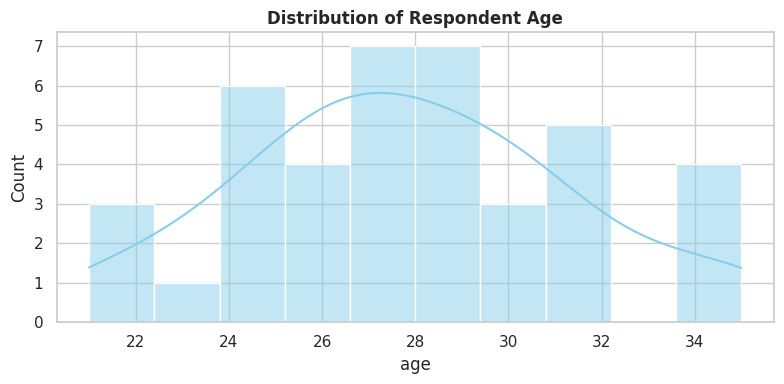

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["age"], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Respondent Age', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### Chart 2 — Preferred Investment Avenue by Gender

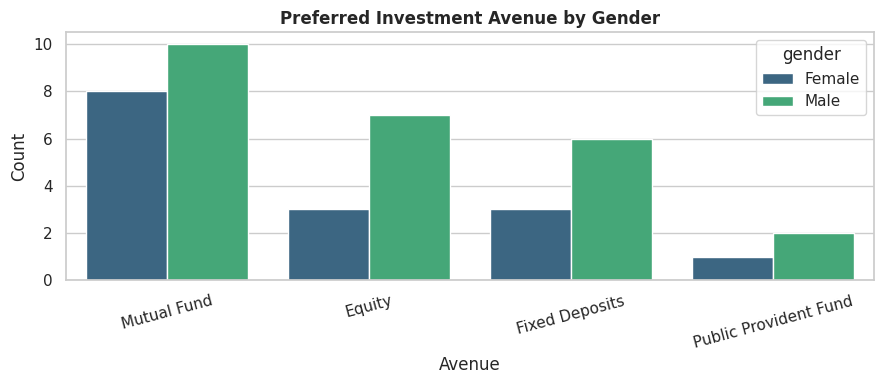

In [9]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x="Avenue", hue="gender", palette='viridis')
plt.title('Preferred Investment Avenue by Gender', fontsize=12, fontweight='bold')
plt.xlabel('Avenue')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Chart 3 — Correlation Between Investment Preference Rankings

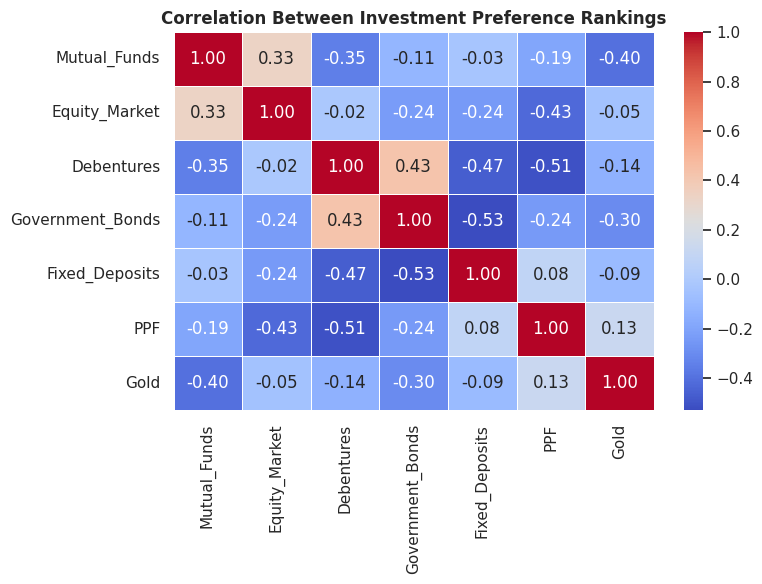

In [10]:
rank_cols = ["Mutual_Funds", "Equity_Market", "Debentures", "Government_Bonds",
             "Fixed_Deposits", "PPF", "Gold"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[rank_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Investment Preference Rankings', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 5: Insights

What the charts actually tell us, in plain English.

In [11]:
print("=== PHASE 2 SUMMARY & KEY INSIGHTS ===")
print(f"1. Sample size caveat: This dataset has only {df.shape[0]} respondents — "
      "patterns below are suggestive, not statistically robust.")
print(f"2. Age range: Respondents are {df['age'].min()}-{df['age'].max()} years old, "
      f"averaging {df['age'].mean():.1f} — a fairly young, likely working-age sample.")
print(f"3. Most preferred avenue: '{df['Avenue'].mode()[0]}' was the most commonly "
      "selected primary investment avenue across respondents.")
print("4. Ranking trade-off: Government Bonds and Fixed Deposits show the strongest "
      "negative correlation in the heatmap (-0.53). Despite both being conservative, "
      "low-risk options, respondents who ranked one highly tended to rank the other "
      "low — treating them as substitutes rather than combining both.")


=== PHASE 2 SUMMARY & KEY INSIGHTS ===
1. Sample size caveat: This dataset has only 40 respondents — patterns below are suggestive, not statistically robust.
2. Age range: Respondents are 21-35 years old, averaging 27.8 — a fairly young, likely working-age sample.
3. Most preferred avenue: 'Mutual Fund' was the most commonly selected primary investment avenue across respondents.
4. Ranking trade-off: Government Bonds and Fixed Deposits show the strongest negative correlation in the heatmap (-0.53). Despite both being conservative, low-risk options, respondents who ranked one highly tended to rank the other low — treating them as substitutes rather than combining both.
